In [1]:
import cobra
from modelseedpy import MSBuilder, MSATPCorrection, MSMedia, MSGapfill
import json
from tqdm import tqdm
import cobrakbase

modelseedpy 0.4.2
cobrakbase 0.4.0


In [2]:
config = cobra.Configuration()
config

Attribute,Description,Value
solver,Mathematical optimization solver,cplex
tolerance,"General solver tolerance (feasibility, integrality, etc.)",1e-07
lower_bound,Default reaction lower bound,-1000.0
upper_bound,Default reaction upper bound,1000.0
processes,Number of parallel processes,335
cache_directory,Path for the model cache,/home/fliu/.cache/cobrapy
max_cache_size,Maximum cache size in bytes,104857600
cache_expiration,Model cache expiration time in seconds (if any),None


In [3]:
mepe = {
    'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}

In [4]:
def _add_atpm(model):
    from cobra.core import Reaction
    if 'ATPM_c0' not in model.reactions:
        atpm = Reaction(f'ATPM_c0', f'ATPM', 'ATPM', 0, 1000)
        atpm.add_metabolites({
            model.metabolites.cpd00001_c0: -1,
            model.metabolites.cpd00002_c0: -1,
            model.metabolites.cpd00008_c0: 1,
            model.metabolites.cpd00009_c0: 1,
            model.metabolites.cpd00067_c0: 1,
        })
        model.add_reactions([atpm])

In [5]:
models_base = {}
for i in tqdm(mepe):
    model = cobra.io.load_json_model(f'./models/{i}__.RAST.json')
    _add_atpm(model)
    models_base[i] = model

100%|██████████| 27/27 [00:14<00:00,  1.93it/s]


In [6]:
for model_name in models_base:
    print(model_name)
    model_base = models_base[model_name]
    disable = ['rxn23850_c0', 'rxn09193_c0', 'rxn05315_c0', 'rxn05206_c0']
    for rxn_id in disable:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0
            rxn.upper_bound = 0
    disable_lb = [
        'rxn09188_c0', 'rxn00929_c0', 
              'rxn00145_c0', 'rxn00499_c0', 'rxn00146_c0',
              'rxn08934_c0', 'rxn08941_c0', 'rxn08935_c0', 'rxn08942_c0', # not sure about these
              'rxn11942_c0', 'rxn11941_c0',
              'rxn43329_c0', 'rxn11940_c0',
              'rxn40559_c0', 'rxn04159_c0', 'rxn04705_c0',
        'rxn14415_c0',
        'sul00003_c0', 'rxn48579_c0',
        'rxn39860_c0'
             ]
    for rxn_id in disable_lb:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0
    rxn_balance_check = ['rxn15395_c0', 'rxn28338_c0']
    for rxn_id in rxn_balance_check:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            check = {'charge': -1, 'H': -1}
            if rxn.check_mass_balance() == check:
                print(rxn)
                rxn.add_metabolites({
                    model_base.metabolites.cpd00067_c0: +1
                })
                print(rxn.check_mass_balance())
    model_base.medium = {
    'EX_cpd00001_e0': 1000,
    'EX_cpd00067_e0': 1000,
    #'EX_cpd00036_e0': 1,
    'EX_cpd00007_e0': 100,
}
    model_base.objective = 'ATPM_c0'
    sol = cobra.flux_analysis.pfba(model_base)
    if sol.fluxes['ATPM_c0'] > 0.0:
        break
print('no moar loops!')

Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
rxn28338_c0: cpd00084_c0 + cpd00790_c0 --> cpd00029_c0 + cpd19019_c0
{}
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs
rxn15395_c0: cpd00084_c0 + cpd00822_c0 --> cpd00036_c0 + cpd19019_c0
{}
rxn28338_c0

In [42]:
for r in model_base.reactions:
    v = sol.fluxes[r.id]
    if v != 0:
        print(r.id, r.build_reaction_string(True), v, r.check_mass_balance())

In [4]:
model_base = models_base['Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs']

In [7]:
model_base

Name,Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST
Memory address,1c3a4410ca0
Number of metabolites,1206
Number of reactions,1244
Number of genes,1141
Number of groups,0
Objective expression,1.0*ATPM_c0 - 1.0*ATPM_c0_reverse_76e6c
Compartments,"Cytosol, Extracellular"


In [10]:
_add_atpm(model_base)

In [21]:
model_base.reactions.rxn09188_c0.lower_bound = 0
model_base.reactions.rxn00929_c0.lower_bound = 0

In [30]:
model_base.reactions.rxn00145_c0.lower_bound = 0
model_base.reactions.rxn00499_c0.lower_bound = 0

In [36]:

model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0

In [41]:
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0


In [43]:

model_base.summary(sol)

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


In [8]:
template_core = cobrakbase.io.load_kbase_zip_object('./CoreBacV5.1.json.zip')

In [9]:
import os


In [17]:
for model_name in models_base:
    print(model_name)
    model_base = models_base[model_name]
    if not os.path.exists(f'./atp/{model_base.id}.json'):
        model_gapfill = model_base.copy()
        atp_correction = MSATPCorrection(model_gapfill, template_core, medias,
                    compartment='c0', 
                    atp_hydrolysis_id='ATPM_c0',
                    load_default_medias=False)
        tests = atp_correction.run_atp_correction()
        atp_data = conv_atp_results(atp_correction, tests)
        with open(f'./atp/{model_base.id}.json', 'w') as fh:
            fh.write(json.dumps(atp_data))
    else:
        print(f'skip {model_name}!')

Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs
skip Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs!
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:Expansion time:empty:0.024326708167791367
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1088
INFO:modelseedpy.core.msmodelutl:Expansion time:Ac.O2:0.012155618984252214
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1088
INFO:modelseedpy.core.msmodelutl:Expansion time:Etho.O2:0.009145119227468967
INFO:modelseedpy.core.msmodel

Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs


INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:mod

Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs


...

INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:mod

Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:Expansion time:empty:0.019313769415020943
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1099
INFO:modelseedpy.core.msmodelutl:Expansion time:Glc.O2:0.013423859141767025
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1099
INFO:modelseedpy.core.msmodelutl:Expansion 

Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:mod

In [16]:
def conv_atp_results(atp_correction, tests):
    results = {'tests': {}, 'gapfill': {}}
    for x in tests:
        results['tests'][x['media'].id] = {
            'is_max_threshold': x['is_max_threshold'], 
            'threshold': x['threshold'], 
            'objective': x['objective'], 
        }
    for x in atp_correction.media_gapfill_stats:
        gp_stats = atp_correction.media_gapfill_stats[x]
        #print(x.id, gp_stats)
        if gp_stats:
            results['gapfill'][x.id] = {
                'reversed': gp_stats.get('reversed'),
                'new': gp_stats.get('new'),
                'target': gp_stats.get('target'),
                'minobjective': gp_stats.get('minobjective'),
                'binary_check': gp_stats.get('binary_check'),
            }
    return results

'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs__.RAST'

In [13]:
media_path = '/Users/fliu/workspace/python/env/modelseed/lib/python3.10/site-packages/modelseedpy/data/atp_medias.tsv'
media_path = '/opt/env/modelseed_cplex/lib/python3.10/site-packages/modelseedpy/data/atp_medias.tsv'

In [14]:
min_gap = {
    "Glc.O2": 5,
    "Etho.O2": 0.01,
    "Ac.O2": 1,
    "Pyr.O2": 3,
    "Glyc.O2": 2,
    "Fum.O2": 3,
    "Succ.O2": 2,
    "Akg.O2": 2,
    "LLac.O2": 2,
    "Dlac.O2": 2,
    "For.O2": 1.875,
    "For.NO3": 1.5,
    "Pyr.NO": 2.5,
    "Pyr.NO2": 2.5,
    "Pyr.NO3": 2.5,
    "Pyr.SO4": 2.5,
}
def load_default_medias(default_media_path='/opt/py'):
    import pandas as pd
    filename = default_media_path
    medias = pd.read_csv(filename, sep="\t", index_col=0).to_dict()
    res = []
    for media_id in medias:
        #print(media_id)
        media_d = {}
        for exchange, v in medias[media_id].items():
            if v > 0:
                k = exchange.split("_")[1]
                media_d[k] = v
        media_d["cpd00001"] = 1000
        media_d["cpd00067"] = 1000
        media = MSMedia.from_dict(media_d)
        media.id = media_id
        media.name = media_id
        min_obj = 0.01
        res.append([media, min_gap.get(media.id, min_obj)])
    return res
medias = load_default_medias(media_path)

In [19]:
atp_data = {}
for i in tqdm(mepe):
    with open(f'./atp/{i}__.RAST.json', 'r') as fh:
        atp_data[i] = json.load(fh)

100%|██████████| 27/27 [00:00<00:00, 2600.61it/s]


In [62]:
genome_core_gf = {}
for genome_id in atp_data:
    genome_core_gf[genome_id] = {}
    _data = atp_data[genome_id]
    for cond_id in _data['gapfill']:
        _gapfill_data = _data['gapfill'][cond_id]
        if _gapfill_data['target']:
            _gap_fill_add = list(filter(lambda x: x[:3] != 'EX_', _gapfill_data['new']))
            genome_core_gf[genome_id][cond_id] = len(_gap_fill_add)

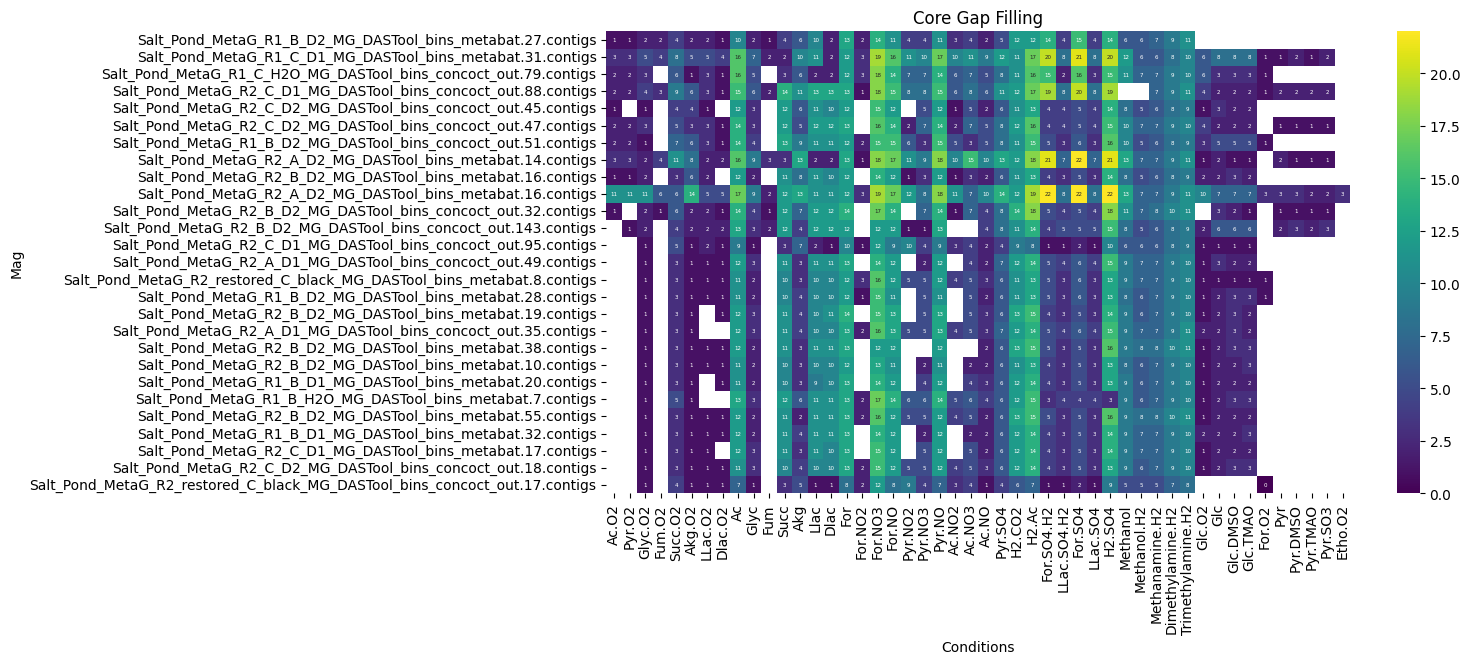

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = genome_core_gf

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("Core Gap Filling")
plt.ylabel("Mag")
plt.xlabel("Conditions")
plt.show()

In [52]:
model_base = models_base['Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs']

In [68]:
atp_data['Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs']['gapfill']['LLac.O2']

{'reversed': {},
 'new': {'EX_cpd00159_e0': '>', 'rxn05602_c0': '>'},
 'target': 'ATPM_c0',
 'minobjective': 2,
 'binary_check': False}

In [65]:
pyr_tmao = list(filter(lambda x: x[0].id == 'Pyr.TMAO', medias))[0][0]
glyc_o2 = list(filter(lambda x: x[0].id == 'Glyc.O2', medias))[0][0]
llac_o2 = list(filter(lambda x: x[0].id == 'LLac.O2', medias))[0][0]

In [66]:
llac_o2.get_media_constraints()

{'cpd00159_e0': (-1, 1000),
 'cpd00007_e0': (-1000, 1000),
 'cpd00001_e0': (-1000, 1000),
 'cpd00067_e0': (-1000, 1000)}

In [72]:
model_base.add_reactions([template_core.reactions.rxn05602_c.to_reaction(model_base)])

In [75]:
MSBuilder.add_exchanges_to_model(model_base)

[<Reaction EX_cpd00159_e0 at 0x7e1abc67da20>]

In [76]:
model_base.medium = {
    'EX_cpd00067_e0': 1000, 
    'EX_cpd00001_e0': 1000, 
    'EX_cpd00007_e0': 1,
    'EX_cpd00159_e0': 1000,
}

In [96]:
rxn_scan = ['rxn26456_c0', 'rxn26457_c0', 'rxs43120_c0', 'rxn26447_c0', 'rxn04651_c0']
_plot_data = {}
for model_id in models_base:
    model_base = models_base[model_id]
    _plot_data[model_id] = {x: x in model_base.reactions for x in rxn_scan}

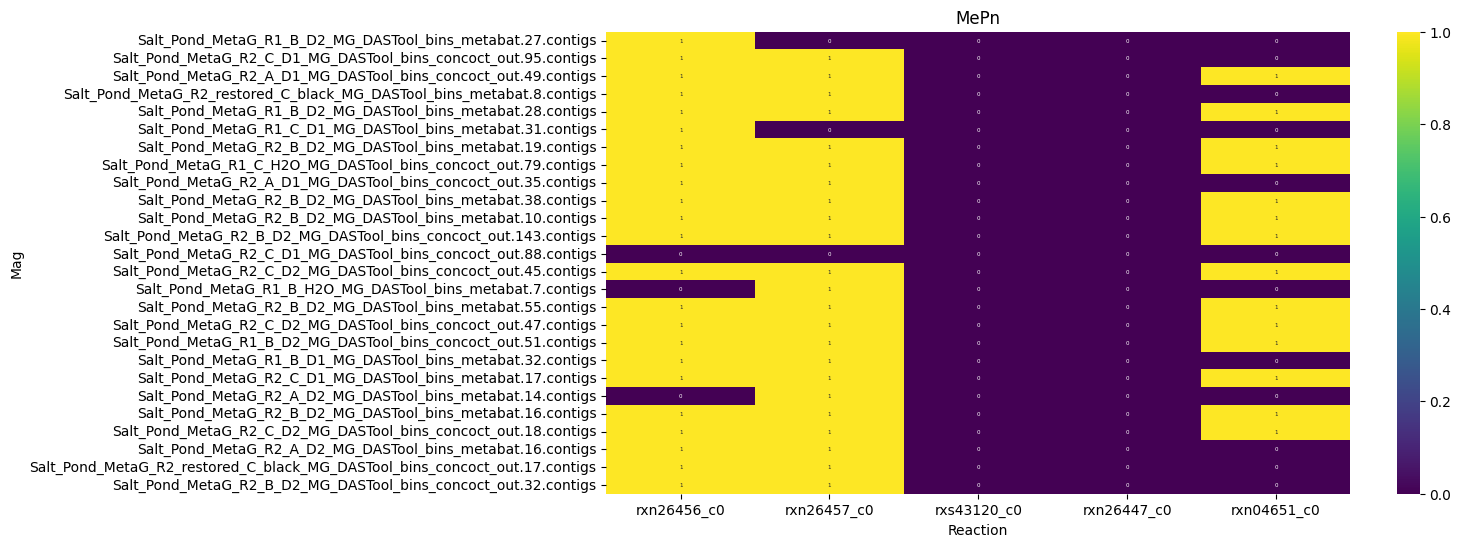

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = _plot_data

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("MePn")
plt.ylabel("Mag")
plt.xlabel("Reaction")
plt.show()

In [118]:
cpd_inject = {'cpd26508_c0', 'cpd01024_c0'}
_to_add = []
for cpd_id in cpd_inject:
    if cpd_id not in model_base.metabolites:
        _to_add.append(template_neg.compcompounds.get_by_id(cpd_id[:-1]).to_metabolite())
model_base.add_metabolites(_to_add)
_to_add

[]

In [152]:
rxs00001_c0 = Reaction('rxs00001_c0', 'MePn ABC Transporter', 'MePn Degradation', 0, 1000)
rxs00001_c0.add_metabolites({
    model_base.metabolites.cpd00001_c0: -1,
    model_base.metabolites.cpd00002_c0: -1,
    model_base.metabolites.cpd00008_c0:  1,
    model_base.metabolites.cpd00009_c0:  1,
    model_base.metabolites.cpd00067_c0:  1,

    model_base.metabolites.cpd25960_e0: -1,
    model_base.metabolites.cpd25960_c0:  1,
})
print(rxs00001_c0.check_mass_balance())
rxs00001_c0

{'charge': -1}


Reaction identifier,rxs00001_c0
Name,MePn ABC Transporter
Memory address,0x7e1abb77db10
Stoichiometry,cpd00001_c0 + cpd00002_c0 + cpd25960_e0 --> cpd00008_c0 + cpd00009_c0 + cpd00067_c0 + cpd25960_c0 H2O [c0] + ATP [c0] + MePn [e0] --> ADP [c0] + Phosphate [c0] + H+ [c0] + MePn [c0]
GPR,
Lower bound,0
Upper bound,1000


In [153]:
model_base.metabolites.cpd25960_c0.charge

-1

In [150]:
from cobra.core import Metabolite
cpd_mepn_e0 = Metabolite('cpd25960_e0', 'CH4O3P', 'MePn [e0]', -1, 'e0')
model_base.add_metabolites([cpd_mepn_e0])

In [128]:
from cobra.core import Reaction
rxs43120_c0 = Reaction('rxs43120_c0', 'rxs43120_c0', 'MePn Degradation', 0, 1000)
rxs43120_c0.add_metabolites({
    model_base.metabolites.cpd00017_c0: -1,
    model_base.metabolites.cpd26519_c0: -1,
    model_base.metabolites.cpd01024_c0:  1,
    model_base.metabolites.cpd03091_c0:  1,
    model_base.metabolites.cpd00060_c0:  1,
    model_base.metabolites.cpd26508_c0:  1,

    model_base.metabolites.cpd00003_c0: +1,
    model_base.metabolites.cpd00004_c0: -1,
})
print(rxs43120_c0.check_mass_balance())
rxs43120_c0

{}


Reaction identifier,rxs43120_c0
Name,rxs43120_c0
Memory address,0x7e1abb787010
Stoichiometry,"cpd00004_c0 + cpd00017_c0 + cpd26519_c0 --> cpd00003_c0 + cpd00060_c0 + cpd01024_c0 + cpd03091_c0 + cpd26508_c0 NADH [c0] + S-Adenosyl-L-methionine [c0] + PRPn [c0] --> NAD [c0] + L-Methionine [c0] + Methane [c0] + 5'-Deoxyadenosine [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0]"
GPR,
Lower bound,0
Upper bound,1000


In [137]:
template_reaction = template_neg.reactions.get_by_id('rxn26456_c')

In [138]:
template_reaction

Reaction identifier,rxn26456_c0
Name,RXN0-6732.c [c0]
Memory address,0x7e1abbc15d20
Stoichiometry,cpd00002_c0 + cpd25960_c0 --> cpd00128_c0 + cpd26518_c0 ATP [c0] + MePn [c0] --> Adenine [c0] + RPnTP [c0]
GPR,
Lower bound,0
Upper bound,1000


In [154]:
pathway_rxn_mepn = [
    rxs00001_c0,
    template_neg.reactions.get_by_id('rxn26456_c').to_reaction(model_base),
    template_neg.reactions.get_by_id('rxn26457_c').to_reaction(model_base),
    rxs43120_c0,
    template_neg.reactions.get_by_id('rxn26447_c').to_reaction(model_base),
    template_neg.reactions.get_by_id('rxn04651_c').to_reaction(model_base),
]
pathway_rxn_mepn[4].add_metabolites({
    model_base.metabolites.cpd00067_c0: -2
})
pathway_rxn_mepn

[<Reaction rxs00001_c0 at 0x7e1abb77db10>,
 <Reaction rxn26456_c0 at 0x7e1abb77c310>,
 <Reaction rxn26457_c0 at 0x7e1abb77d7b0>,
 <Reaction rxs43120_c0 at 0x7e1abb787010>,
 <Reaction rxn26447_c0 at 0x7e1abb77d9c0>,
 <Reaction rxn04651_c0 at 0x7e1ab7a986a0>]

In [174]:
for rxn in pathway_rxn_mepn:
    print(rxn.id)
    print(rxn.build_reaction_string(True))
    print(rxn.check_mass_balance())
    print()

rxs00001_c0
H2O [c0] + ATP [c0] + MePn [e0] --> ADP [c0] + Phosphate [c0] + H+ [c0] + MePn [c0]
{'charge': -1}

rxn26456_c0
ATP [c0] + MePn [c0] --> Adenine [c0] + RPnTP [c0]
{}

rxn26457_c0
H2O [c0] + RPnTP [c0] --> PPi [c0] + 2 H+ [c0] + PRPn [c0]
{}

rxs43120_c0
NADH [c0] + S-Adenosyl-L-methionine [c0] + PRPn [c0] --> NAD [c0] + L-Methionine [c0] + Methane [c0] + 5'-Deoxyadenosine [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0]
{}

rxn26447_c0
H2O [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0] <=> H+ [c0] + Ribose 1,5-bisphosphate [c0]
{'charge': 2, 'H': 2}

rxn04651_c0
ATP [c0] + Ribose 1,5-bisphosphate [c0] --> ADP [c0] + H+ [c0] + PRPP [c0]
{}



In [182]:
pathway_rxn_mepn_total = pathway_rxn_mepn[0] + pathway_rxn_mepn[1] + pathway_rxn_mepn[2] + pathway_rxn_mepn[3] + pathway_rxn_mepn[4] + pathway_rxn_mepn[5]
pathway_rxn_mepn_total.check_mass_balance()

In [183]:
pathway_rxn_mepn_total.check_mass_balance()

{'charge': -1}

In [81]:
model_base.reactions.rxn26457_c0

Reaction identifier,rxn26457_c0
Name,RXN0-6733.c [c0]
Memory address,0x7e4864307d90
Stoichiometry,cpd00001_c0 + cpd26518_c0 --> cpd00012_c0 + 2 cpd00067_c0 + cpd26519_c0 H2O [c0] + RPnTP [c0] --> PPi [c0] + 2 H+ [c0] + PRPn [c0]
GPR,Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs__.RAST.CDS.2006 or...
Lower bound,0.0
Upper bound,1000.0


In [85]:
model_base.reactions.rxn26447_c0

AttributeError: DictList has no attribute or entry rxn26447_c0

In [82]:
template_neg = cobrakbase.io.load_kbase_zip_object('./GramNegModelTemplateV6_test.json.zip')

In [129]:
pathway_rast_mepn = {
'phnCDE': [
        'Phosphonate ABC transporter substrate-binding protein PhnD (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter ATP-binding protein PhnC (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1); Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
    ],
    'phnI': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)'
    ],
    'phnM': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)'
    ],
    'phnJ': [
        'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)'
    ],
    'phnN': [
        'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
    ],
}

In [171]:
import tarfile
from tqdm import tqdm
rast_annotation = {}
with tarfile.open('/storage/fliu/data/cliff/genomes/salterns.rast.tar.gz', "r:gz") as fh_tar:
    for member in tqdm(fh_tar.getmembers()):
        if member.isfile():
            file = fh_tar.extractfile(member)
            if file:
                content = file.read()
                rast_data = json.loads(bytearray(content))
                _d = {}
                for o in rast_data[0]['features']:
                    _d[o['id']] = o.get('function', 'hypothetical protein')
                rast_annotation.update(_d)
len(rast_annotation)

ani_library_derep_genomes.txt  fna  salterns.rast.tar.gz


100%|██████████| 68/68 [00:19<00:00,  3.43it/s]


1358000

In [195]:
for i, model in models_base.items():
    for rxn in pathway_rxn_mepn:
        if rxn.id not in model.reactions:
            #print(i, rxn)
            pass
        else:
            print(i, rxn.id)

Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs rxn26456_c0
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs rxn26456_c0
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs rxn26457_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn26456_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn26457_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn04651_c0
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs rxn26456_c0
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs rxn26457_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn26456_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn26457_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn04651_c0
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs rxn26456_c0
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs rxn26456_c0
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_

## Load and Fix Template

In [9]:
template_neg = cobrakbase.io.load_kbase_zip_object('./GramNegModelTemplateV6_test.json.zip')
from modelseedpy.core.mstemplate import MSTemplateReaction, MSTemplateSpecies
template_neg.add_comp_compounds([
    MSTemplateSpecies('cpd25960_e', template_neg.compcompounds.cpd25960_c.charge, 'e', 'cpd25960')
])
rxs43120_c0 = MSTemplateReaction('rxs43120_c', 'rxs43120', 'rxs43120', 'MePn Degradation', 0, 1000, gapfill_direction='>')
rxs43120_c0.add_metabolites({
    template_neg.compcompounds.cpd00017_c: -1,
    template_neg.compcompounds.cpd26519_c: -1,
    template_neg.compcompounds.cpd01024_e:  1,
    template_neg.compcompounds.cpd03091_c:  1,
    template_neg.compcompounds.cpd00060_c:  1,
    template_neg.compcompounds.cpd26508_c:  1,

    template_neg.compcompounds.cpd00003_c: +1,
    template_neg.compcompounds.cpd00004_c: -1,
})
print(rxs43120_c0.check_mass_balance())
rxs00001_c0 = MSTemplateReaction('rxs00001_c', 'rxs00001', 'MePn ABC Transporter', 'MePn Degradation', 0, 1000, gapfill_direction='>')
rxs00001_c0.add_metabolites({
    template_neg.compcompounds.cpd00001_c: -1,
    template_neg.compcompounds.cpd00002_c: -1,
    template_neg.compcompounds.cpd00008_c:  1,
    template_neg.compcompounds.cpd00009_c:  1,
    template_neg.compcompounds.cpd00067_c:  1,

    template_neg.compcompounds.cpd25960_e: -1,
    template_neg.compcompounds.cpd25960_c:  1,
})
print(rxs00001_c0.check_mass_balance())
template_neg.add_reactions([rxs43120_c0, rxs00001_c0])
template_neg.reactions.rxn26447_c.add_metabolites({
    template_neg.compcompounds.cpd00067_c: -2
})
print(template_neg.reactions.rxn26447_c.check_mass_balance())
disable = ['rxn23850_c', 'rxn09193_c', 'rxn05315_c', 'rxn05206_c']
_remove = []
for rxn_id in disable:
    if rxn_id in template_neg.reactions:
        _remove.append(rxn_id)
template_neg.reactions -= _remove
disable_lb = [
        'rxn09188_c', 'rxn00929_c', 
        'rxn00145_c', 'rxn00499_c', 'rxn00146_c',
              'rxn08934_c', 'rxn08941_c', 'rxn08935_c', 'rxn08942_c', # not sure about these
              'rxn11942_c', 'rxn11941_c',
              'rxn43329_c', 'rxn11940_c',
              'rxn40559_c', 'rxn04159_c', 'rxn04705_c',
        'rxn14415_c',
        'sul00003_c', 'rxn48579_c',
        'rxn39860_c'
             ]
for rxn_id in disable_lb:
    template_reaction = template_neg.reactions.get_by_id(rxn_id)
    template_reaction.lower_bound = 0

{}
{}
{}


## ATP test

In [10]:
def manual_add_core_gapfill(model_base):
    rxn_manual_gap = {'rxn05602_c': 'rxn05602_c0'}
    rxn_to_add = []
    for rxn_id, rxn_model_id in rxn_manual_gap.items():
        if rxn_model_id not in model_base.reactions:
            template_reaction = template_neg.reactions.get_by_id(rxn_id)
            rxn_to_add.append(template_reaction.to_reaction(model_base))
    model_base.add_reactions(rxn_to_add)
    return MSBuilder.add_exchanges_to_model(model_base)

In [11]:
atp_ready = {}
for model_id, model in tqdm(models_base.items()):
    manual_add_core_gapfill(model)
    model.objective = 'ATPM_c0'
    model.medium = {
        'EX_cpd00159_e0': 1,
        'EX_cpd00007_e0': 1000,
        'EX_cpd00067_e0': 1000,
        'EX_cpd00001_e0': 1000
    }
    solution = cobra.flux_analysis.pfba(model)
    if solution.fluxes['ATPM_c0'] > 1:
        atp_ready[model_id] = solution.fluxes['ATPM_c0']

100%|██████████| 27/27 [00:13<00:00,  2.05it/s]


In [12]:
def add_mepn(model_base):
    pathway_rxn_mepn = {
    'rxs00001_c': 'rxs00001_c0', 
    'rxn26456_c': 'rxn26456_c0', 
    'rxn26457_c': 'rxn26457_c0', 
    'rxs43120_c': 'rxs43120_c0', 
    'rxn26447_c': 'rxn26447_c0', 
    'rxn04651_c': 'rxn04651_c0', 
    }
    rxn_to_add = []
    for rxn_id, rxn_model_id in pathway_rxn_mepn.items():
        if rxn_model_id not in model_base.reactions:
            template_reaction = template_neg.reactions.get_by_id(rxn_id)
            rxn_to_add.append(template_reaction.to_reaction(model_base))
    model_base.add_reactions(rxn_to_add)
    MSBuilder.add_exchanges_to_model(model_base)
for model_id, model in tqdm(models_base.items()):
    add_mepn(model)

100%|██████████| 27/27 [00:00<00:00, 322.93it/s]


In [26]:
pathway_rxn_mepn_total = pathway_rxn_mepn[0] + pathway_rxn_mepn[1] + pathway_rxn_mepn[2] + pathway_rxn_mepn[3] + pathway_rxn_mepn[4] + pathway_rxn_mepn[5]


[]

In [60]:
pathway_rxn_mepn_total = model_base.reactions.rxs00001_c0 + model_base.reactions.rxn26456_c0 + model_base.reactions.rxn26457_c0 + model_base.reactions.rxs43120_c0 + model_base.reactions.rxn26447_c0 + model_base.reactions.rxn04651_c0
pathway_rxn_mepn_total.check_mass_balance()

{}

In [61]:
pathway_rxn_mepn_total

Reaction identifier,rxs00001_c0
Name,MePn ABC Transporter [c0]
Memory address,0x1c3b0953400
Stoichiometry,3 cpd00001_c0 + 3 cpd00002_c0 + cpd00004_c0 + cpd00017_c0 + cpd25960_e0 --> cpd00003_c0 + 2 cpd00008_c0 + cpd00009_c0 + cpd00012_c0 + cpd00060_c0 + 3 cpd00067_c0 + cpd00103_c0 + cpd00128_c0 +... 3 H2O [c0] + 3 ATP [c0] + NADH [c0] + S-Adenosyl-L-methionine [c0] + MePn [e0] --> NAD [c0] + 2 ADP [c0] + Phosphate [c0] + PPi [c0] + L-Methionine [c0] + 3 H+ [c0] + PRPP [c0] + Adenine [c0] +...
GPR,((Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.3016 and...
Lower bound,0
Upper bound,1000


In [32]:
for rxn in model_base.reactions:
    v = solution.fluxes[rxn.id]
    if v != 0:
        print(rxn.id, rxn.build_reaction_string(True), v)

rxn00199_c0 H+ [c0] + Oxalosuccinate [c0] --> CO2 [c0] + 2-Oxoglutarate [c0] 1.0
rxn02376_c0 Lipoamide [c0] + 3-Carboxy-1-hydroxypropyl-ThPP [c0] <=> TPP [c0] + S-Succinyldihydrolipoamide [c0] 1.0
rxn01872_c0 Succinyl-CoA [c0] + Dihydrolipoamide [c0] <=> CoA [c0] + S-Succinyldihydrolipoamide [c0] -1.0
rxn00248_c0 NAD [c0] + L-Malate [c0] <=> NADH [c0] + Oxaloacetate [c0] + H+ [c0] 1.0
rxn00499_c0 NAD [c0] + L-Lactate [c0] --> NADH [c0] + Pyruvate [c0] + H+ [c0] 1.0
rxn00285_c0 ATP [c0] + CoA [c0] + Succinate [c0] <=> ADP [c0] + Phosphate [c0] + Succinyl-CoA [c0] -1.0
rxn10122_c0 NADH [c0] + 4.5 H+ [c0] + Ubiquinone-8 [c0] --> NAD [c0] + 3.5 H+ [e0] + Ubiquinol-8 [c0] 6.0
rxn00611_c0 NAD [c0] + Glycerol-3-phosphate [c0] <=> NADH [c0] + H+ [c0] + Glycerone-phosphate [c0] 1.0
rxn00616_c0 FAD [c0] + H+ [c0] + Glycerol-3-phosphate [c0] <=> Glycerone-phosphate [c0] + FADH2 [c0] -1.0
rxn00799_c0 L-Malate [c0] <=> H2O [c0] + Fumarate [c0] -1.0
rxn01387_c0 NADP [c0] + Isocitrate [c0] <=> NADPH 

In [20]:
for r in model_base.metabolites.cpd00159_c0.reactions:
    print(r.id, r.build_reaction_string(True))
    print('\t', r.gene_reaction_rule)

rxn08792_c0 L-Lactate [c0] + Ubiquinone-8 [c0] --> Pyruvate [c0] + Ubiquinol-8 [c0]
	 Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.1120 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.3629 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.4392
rxn00145_c0 2 Cytochrome c3+ [c0] + L-Lactate [c0] --> Pyruvate [c0] + 2 H+ [c0] + 2 Cytochrome c2+ [c0]
	 Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.1120 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.3629 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.4392
rxn08793_c0 L-Lactate [c0] + Menaquinone 8 [c0] --> Pyruvate [c0] + Menaquinol 8 [c0]
	 Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.1120 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.3629 or Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST.CDS.4392
rxn00499_c0 NAD [c0] + L-L

In [62]:
kbase = cobrakbase.KBaseAPI('555LI5PO2NYLO6VM3CSVYI7GLBC4P7QM')

In [64]:
kbase_media = kbase.get_from_ws('Carbon-D-Glucose', 12218)

In [69]:
for m in kbase_media.get_media_constraints():
    ccpd = template_neg.compcompounds.get_by_id(m[:-1])
    print('EX_' + ccpd.id + '0', ccpd.name)

EX_cpd00149_e0 Co2+ [e]
EX_cpd00099_e0 Cl- [e]
EX_cpd00067_e0 H+ [e]
EX_cpd00063_e0 Ca2+ [e]
EX_cpd00058_e0 Cu2+ [e]
EX_cpd00048_e0 Sulfate [e]
EX_cpd00034_e0 Zn2+ [e]
EX_cpd00030_e0 Mn2+ [e]
EX_cpd00013_e0 NH3 [e]
EX_cpd00009_e0 Phosphate [e]
EX_cpd00001_e0 H2O [e]
EX_cpd00007_e0 O2 [e]
EX_cpd00205_e0 K+ [e]
EX_cpd00254_e0 Mg [e]
EX_cpd00971_e0 Na+ [e]
EX_cpd10515_e0 Fe2+ [e]
EX_cpd10516_e0 fe3 [e]
EX_cpd11574_e0 Molybdate [e]
EX_cpd00244_e0 Ni2+ [e]
EX_cpd00027_e0 D-Glucose [e]


In [73]:
model_base.objective = 'ATPM_c0'
model_base.medium = {
    'EX_cpd00159_e0': 1,
    'EX_cpd00007_e0': 1000,
    'EX_cpd00067_e0': 1000,
    'EX_cpd00001_e0': 1000,

    'EX_cpd25960_e0': 1000,

    'EX_cpd00149_e0': 1000, # Co2+ [e]
    'EX_cpd00099_e0': 1000, # Cl- [e]
    'EX_cpd00063_e0': 1000, # Ca2+ [e]

    'EX_cpd00058_e0': 1000, # Cu2+ [e]
    'EX_cpd00048_e0': 1000, # Sulfate [e]
    'EX_cpd00034_e0': 1000, # Zn2+ [e]
    'EX_cpd00030_e0': 1000, # Mn2+ [e]
    'EX_cpd00013_e0': 1000, # NH3 [e]

    'EX_cpd00205_e0': 1000, # K+ [e]
    'EX_cpd00254_e0': 1000, # Mg [e]
    'EX_cpd00971_e0': 1000, # Na+ [e]
    #'EX_cpd10515_e0': 1000, # Fe2+ [e]
    'EX_cpd10516_e0': 1000, # fe3 [e]
    'EX_cpd11574_e0': 1000, # Molybdate [e]
    'EX_cpd00244_e0': 1000, # Ni2+ [e]
}

In [75]:
model_base.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007_e0,EX_cpd00007_e0,3,0,0.00%
cpd00067_e0,EX_cpd00067_e0,1,0,0.00%
cpd00159_e0,EX_cpd00159_e0,1,3,100.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00001_e0,EX_cpd00001_e0,-3,0,0.00%
cpd00011_e0,EX_cpd00011_e0,-3,1,100.00%


In [16]:
M_GENOME_SCALE = {
    'EX_cpd00159_e0': 1,
    'EX_cpd00007_e0': 1000,
    'EX_cpd00067_e0': 1000,
    'EX_cpd00001_e0': 1000,

    'EX_cpd25960_e0': 1000,

    'EX_cpd00149_e0': 1000, # Co2+ [e]
    'EX_cpd00099_e0': 1000, # Cl- [e]
    'EX_cpd00063_e0': 1000, # Ca2+ [e]

    'EX_cpd00058_e0': 1000, # Cu2+ [e]
    'EX_cpd00048_e0': 1000, # Sulfate [e]
    'EX_cpd00034_e0': 1000, # Zn2+ [e]
    'EX_cpd00030_e0': 1000, # Mn2+ [e]
    'EX_cpd00013_e0': 1000, # NH3 [e]

    'EX_cpd00205_e0': 1000, # K+ [e]
    'EX_cpd00254_e0': 1000, # Mg [e]
    'EX_cpd00971_e0': 1000, # Na+ [e]
    'EX_cpd10515_e0': 1000, # Fe2+ [e]
    'EX_cpd10516_e0': 1000, # fe3 [e]
    'EX_cpd11574_e0': 1000, # Molybdate [e]
    'EX_cpd00244_e0': 1000, # Ni2+ [e]
    
    'EX_cpd00305_e0': 100.0, # thiamin
}
def _get_solution(template, gf, sol, model):
    res = {}
    for rxn in gf.gfmodel.reactions:
        v = round(sol.fluxes[rxn.id], 9)
        if v != 0:
            if rxn.id not in model.reactions:
                if rxn.id[:-1] in template.reactions:
                    # print(v, rxn.id, rxn.build_reaction_string(True))
                    lb = -1000
                    ub = 1000
                    if v > 0:
                        lb = 0
                    elif v < 0:
                        ub = 0
                    res[rxn.id[:-1]] = (lb, ub)
    return res
def _integrate_solution(template, model, gap_fill_solution):
    added_reactions = []
    for rxn_id, (lb, ub) in gap_fill_solution.items():
        template_reaction = template.reactions.get_by_id(rxn_id)
        model_reaction = template_reaction.to_reaction(model)
        model_reaction.lower_bound = lb
        model_reaction.upper_bound = ub
        _str = model_reaction.build_reaction_string(True)
        #print(f'{model.id} add {model_reaction.id}: {_str}')
        added_reactions.append(model_reaction)
    model.add_reactions(added_reactions)
    add_exchanges = MSBuilder.add_exchanges_to_model(model)

    return added_reactions, add_exchanges
from cobra.core import Reaction
def _add_dm(model_gapfill):
    to_add = []
    for k, (lb, ub) in template_neg.drains.items():
        if k.id + '0' in model_gapfill.metabolites:
            cpd = model_gapfill.metabolites.get_by_id(k.id + '0')
            dm_id = f'SK_{k.id}0'
            if dm_id not in model_gapfill.reactions:
                rxn_dm = Reaction(dm_id, f'Sink for {k.name}', 'sinks', lb, ub)
                rxn_dm.add_metabolites({
                    cpd: -1
                })
                to_add.append(rxn_dm)
                print(k, dm_id, rxn_dm.name, rxn_dm)
    model_gapfill.add_reactions(to_add)

In [14]:
def gapfill(model_base):
    model = model_base.copy()
    min_biomass = 0.02
    model.objective = 'bio1'
    gapfill = MSGapfill(model, default_gapfill_templates=[template_neg], test_conditions={}, default_target='bio1')
    gapfill.gfmodel.reactions.bio1.lower_bound = min_biomass
    gapfill.gfmodel.medium = M_GENOME_SCALE
    gapfill_fba = gapfill.gfmodel.optimize()
    gapfill_solution = _get_solution(template_neg, gapfill, gapfill_fba, model)
    model_gapfill = model_base.copy()
    _integrate_solution(template_neg, model_gapfill, gap_fill_solution=gapfill_solution)
    _add_dm(model_gapfill)
    return model_gapfill, gapfill_fba

In [32]:
for model_id in atp_ready:
    model = models_base[model_id]
    model_gf, gapfill_fba = gapfill(model)
    model_gf.objective = 'bio1'
    model_gf.medium = {k:v for k, v in M_GENOME_SCALE.items() if k in model_gf.reactions}
    model_gf.id = model_id
    sol = cobra.flux_analysis.pfba(model_gf)
    growth = sol.fluxes['bio1']
    if growth >= 0.02:
        print(f'save {model_id} {len(model_gf.reactions)}')
        cobra.io.save_json_model(model_gf, f'./genome_scale/{model_id}.json')
    else:
        print(f'fail {model_id} {len(model_gf.reactions)}')

cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 
save Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs 1177
cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 
save Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs 1154
cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 
save Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs 1210
cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 
save Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs 1099
cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 
save Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs 1227
cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0

In [19]:
m_sum = {}
for rxn_id, v in gapfill_fba.fluxes.to_dict().items():
    if v != 0:
        if rxn_id.startswith('DM'):
            if rxn_id not in model_gf.reactions:
                rxn = model_gf.reactions.get_by_id('SK' + rxn_id[2:])
                if v > rxn.upper_bound or v < rxn.lower_bound:
                    print('!', rxn.id)
                for m, s in rxn.metabolites.items():
                    if m.id not in m_sum:
                        m_sum[m.id] = 0
                    m_sum[m.id] += s * v
        else:
            rxn = model_gf.reactions.get_by_id(rxn_id)
            if v > rxn.upper_bound or v < rxn.lower_bound:
                print('!', rxn.id)
            for m, s in rxn.metabolites.items():
                if m.id not in m_sum:
                    m_sum[m.id] = 0
                m_sum[m.id] += s * v

! EX_cpd00305_e0
! EX_cpd10516_e0


In [54]:
model_gf.reactions.rxn05315_c0

Reaction identifier,rxn05315_c0
Name,ZN2t4 [c0]
Memory address,0x78c835f34970
Stoichiometry,cpd00034_c0 + cpd00067_e0 + cpd00205_e0 --> cpd00034_e0 + cpd00067_c0 + cpd00205_c0 Zn2+ [c0] + H+ [e0] + K+ [e0] --> Zn2+ [e0] + H+ [c0] + K+ [c0]
GPR,Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs__.RAST.CDS.1390
Lower bound,0
Upper bound,0


In [49]:
import math
for m, v in m_sum.items():
    _v = math.fabs(v)
    if _v > 0:
        print(m, _v)

cpd00067_c0 6.685597171360302e-16
cpd00103_c0 1.734723475976807e-18
cpd00114_c0 8.673617379884035e-19
cpd00002_c0 7.77047697020361e-16
cpd00008_c0 6.94702542020087e-16
cpd00046_c0 1.3010426069826053e-18
cpd00014_c0 2.168404344971009e-19
cpd00011_c0 1.8385358339922941e-16
cpd00024_c0 1.3530843112619095e-16
cpd00009_c0 1.927711462679227e-16
cpd00475_c0 5.421010862427522e-20
cpd00018_c0 8.72782748850831e-18
cpd00106_c0 1.328147661294743e-18
cpd02557_c0 5.421010862427522e-20
cpd00052_c0 1.0028870095490916e-17
cpd00084_c0 6.2341624917916505e-19
cpd00023_c0 1.734723475976807e-17
cpd00010_c0 3.4314998759166215e-17
cpd00113_c0 2.168404344971009e-19
cpd00001_c0 5.464378949326942e-16
cpd00171_c0 4.607859233063394e-19
cpd00095_c0 1.3010426069826053e-18
cpd00102_c0 7.399679827213568e-18
cpd00061_c0 3.469446951953614e-18
cpd00041_c0 7.806255641895632e-18
cpd11492_c0 8.673617379884035e-19
cpd11493_c0 1.0842021724855044e-18
cpd00053_c0 6.29108310584714e-17
cpd00029_c0 4.5536491244391186e-17
cpd00239_

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


In [35]:
model_gf.objective = 'bio1'
model_gf.medium = {'EX_cpd00159_e0': 1,
 'EX_cpd00007_e0': 1000,
 'EX_cpd00067_e0': 1000,
 'EX_cpd00001_e0': 1000,
 'EX_cpd25960_e0': 1000,
 'EX_cpd00149_e0': 1000,
 'EX_cpd00099_e0': 1000,
 'EX_cpd00063_e0': 1000,
 'EX_cpd00058_e0': 1000,
 'EX_cpd00048_e0': 1000,
 'EX_cpd00034_e0': 1000,
 'EX_cpd00030_e0': 1000,
 'EX_cpd00013_e0': 1000,
 'EX_cpd00205_e0': 1000,
 'EX_cpd00254_e0': 1000,
 'EX_cpd00971_e0': 1000,
 'EX_cpd10515_e0': 1000,
 'EX_cpd10516_e0': 1000,
 'EX_cpd11574_e0': 1000,
 'EX_cpd00244_e0': 1000,
 'EX_cpd00305_e0': 100.0}
model_gf.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


In [101]:
for k in gapfill_solution:
    print(k, template_neg.reactions.get_by_id(k).build_reaction_string(True))

rxn12008_c PPi [c] + H+ [c] + Farnesylfarnesylgeraniol [c] <-- Isopentenyldiphosphate [c] + all-trans-Heptaprenyl diphosphate [c]
rxn08333_c 1-4-Dihydroxy-2-naphthoate [c] + Farnesylfarnesylgeraniol [c] --> CO2 [c] + PPi [c] + 2-Demethylmenaquinol 8 [c]
rxn00738_c H2O [c] + 1-Aminocyclopropane-1-carboxylate [c] <=> NH3 [c] + 2-Oxobutyrate [c]
rxn02898_c Succinylbenzoyl-CoA [c] --> CoA [c] + 1-4-Dihydroxy-2-naphthoate [c]
rxn10336_c 2 Phosphatidylglycerol dioctadecanoyl [c] <=> Glycerol [c] + Stearoylcardiolipin (B. subtilis) [c]
rxn05235_c CTP [c] + trdrd [c] --> H2O [c] + dCTP [c] + trdox [c]
rxn02988_c 2 H2O [c] + Phosphate [c] + Quinolinate [c] <-- Glycerone-phosphate [c] + Iminoaspartate [c]
rxn01331_c H2O [c] + NAD [c] + D-Erythrose4-phosphate [c] --> NADH [c] + 2 H+ [c] + 4-Phosphoerythronate [c]
rxn05459_c CoA [c] + H+ [c] + Octodecanoyl-ACP [c] <=> strcoa [c] + ACP [c]
rxn00128_c S-Adenosyl-L-methionine [c] <=> H+ [c] + 5-Methylthioadenosine [c] + 1-Aminocyclopropane-1-carboxyl

In [102]:
model_gapfill = model_base.copy()

In [103]:
_integrate_solution(template_neg, model_gapfill, gap_fill_solution=gapfill_solution)

Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn12008_c0: PPi [c0] + H+ [c0] + Farnesylfarnesylgeraniol [c0] <-- Isopentenyldiphosphate [c0] + all-trans-Heptaprenyl diphosphate [c0]
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn08333_c0: 1-4-Dihydroxy-2-naphthoate [c0] + Farnesylfarnesylgeraniol [c0] --> CO2 [c0] + PPi [c0] + 2-Demethylmenaquinol 8 [c0]
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn00738_c0: H2O [c0] + 1-Aminocyclopropane-1-carboxylate [c0] <-- NH3 [c0] + 2-Oxobutyrate [c0]
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn02898_c0: Succinylbenzoyl-CoA [c0] --> CoA [c0] + 1-4-Dihydroxy-2-naphthoate [c0]
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn10336_c0: 2 Phosphatidylglycerol dioctadecanoyl [c0] --> Glycerol [c0] + Stearoylcardiolipin (B. subtilis) [c0]
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs__.RAST add rxn05235_c0: CT

([<Reaction rxn12008_c0 at 0x1c466fb41f0>,
  <Reaction rxn08333_c0 at 0x1c466fb4160>,
  <Reaction rxn00738_c0 at 0x1c466fb41c0>,
  <Reaction rxn02898_c0 at 0x1c466dcb2e0>,
  <Reaction rxn10336_c0 at 0x1c466dcb5e0>,
  <Reaction rxn05235_c0 at 0x1c466dcb730>,
  <Reaction rxn02988_c0 at 0x1c466dcb760>,
  <Reaction rxn01331_c0 at 0x1c466dcba60>,
  <Reaction rxn05459_c0 at 0x1c466dcbb20>,
  <Reaction rxn00128_c0 at 0x1c466dcbb80>,
  <Reaction rxn00068_c0 at 0x1c466dcbc10>,
  <Reaction rxn00907_c0 at 0x1c466dcbf10>,
  <Reaction rxn10213_c0 at 0x1c466dcbfa0>,
  <Reaction rxn02404_c0 at 0x1c466dcbdc0>,
  <Reaction rxn05039_c0 at 0x1c466dcbf40>,
  <Reaction rxn00336_c0 at 0x1c465bb3f40>,
  <Reaction rxn03891_c0 at 0x1c467086bc0>,
  <Reaction rxn10204_c0 at 0x1c467086c50>,
  <Reaction rxn00656_c0 at 0x1c467086f50>,
  <Reaction rxn03617_c0 at 0x1c4670870a0>,
  <Reaction rxn03159_c0 at 0x1c4591b6860>,
  <Reaction rxn03397_c0 at 0x1c465af2230>,
  <Reaction rxn01423_c0 at 0x1c465af26b0>,
  <Reaction

In [93]:
def _integrate_solution(template, model, gap_fill_solution):
    added_reactions = []
    for rxn_id, (lb, ub) in gap_fill_solution.items():
        template_reaction = template.reactions.get_by_id(rxn_id)
        model_reaction = template_reaction.to_reaction(model)
        model_reaction.lower_bound = lb
        model_reaction.upper_bound = ub
        _str = model_reaction.build_reaction_string(True)
        print(f'{model.id} add {model_reaction.id}: {_str}')
        added_reactions.append(model_reaction)
    model.add_reactions(added_reactions)
    add_exchanges = MSBuilder.add_exchanges_to_model(model)

    return added_reactions, add_exchanges

In [135]:
model_gapfill.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007_e0,EX_cpd00007_e0,1.004,0,0.00%
cpd00013_e0,EX_cpd00013_e0,0.411,0,0.00%
cpd00030_e0,EX_cpd00030_e0,8.071E-05,0,0.00%
cpd00034_e0,EX_cpd00034_e0,8.071E-05,0,0.00%
cpd00048_e0,EX_cpd00048_e0,0.01069,0,0.00%
cpd00058_e0,EX_cpd00058_e0,8.071E-05,0,0.00%
cpd00063_e0,EX_cpd00063_e0,8.071E-05,0,0.00%
cpd00067_e0,EX_cpd00067_e0,0.6682,0,0.00%
cpd00099_e0,EX_cpd00099_e0,8.071E-05,0,0.00%
cpd00149_e0,EX_cpd00149_e0,8.071E-05,0,0.00%


In [ ]:
for gapfill_solution

In [134]:
for rxn_id, v in gapfill_fba.fluxes.to_dict().items():
    if v != 0:
        model_gapfill.reactions.get_by_id(rxn_id)

KeyError: 'DM_cpd02701_c0'

cpd02701_c SK_cpd02701_c0 Sink for S-Adenosyl-4-methylthio-2-oxobutanoate [c] SK_cpd02701_c0: cpd02701_c0 --> 


In [123]:
template_neg.drains

{<NewModelTemplateCompCompound cpd01042_c at 0x1c3b2b767a0>: (0, 1000),
 <NewModelTemplateCompCompound cpd02701_c at 0x1c3b2c60880>: (0, 1000),
 <NewModelTemplateCompCompound cpd03091_c at 0x1c3aed81390>: (0, 1000),
 <NewModelTemplateCompCompound cpd11416_c at 0x1c3aed50550>: (0, 1000),
 <NewModelTemplateCompCompound cpd15302_c at 0x1c3b2c2ba90>: (0, 1000),
 <NewModelTemplateCompCompound cpd22811_c at 0x1c3b2e75450>: (0, 1000)}

In [33]:
model = models_base['Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs']

In [39]:
rxn_growth_phosphate_acc = Reaction('bio_p', 'Growth with Phosphate Accumulation', 'growth', 0, 1000)
rxn_growth_phosphate_acc.add_metabolites({
    model.metabolites.cpd11416_c0: -1
    model.metabolites.cpd00009_c0: -1
    model.metabolites.cpd00012_c0: -1
})
rxn_growth_phosphate_acc

Reaction identifier,bio_p
Name,Growth with Phosphate Accumulation
Memory address,0x780c79d51660
Stoichiometry,cpd11416_c0 --> Biomass [c0] -->
GPR,
Lower bound,0
Upper bound,1000


Metabolite identifier,cpd11416_c0
Name,Biomass [c0]
Memory address,0x780f32316830
Formula,null
Compartment,c0
In 2 reaction(s),"SK_cpd11416_c0, bio1"


In [36]:
model.reactions.bio1.metabolites

{<Metabolite cpd00001_c0 at 0x780f3221bd60>: -40.0,
 <Metabolite cpd00002_c0 at 0x780f32251120>: -40.0,
 <Metabolite cpd00003_c0 at 0x780f322501f0>: -0.0015697387191513736,
 <Metabolite cpd00006_c0 at 0x780f3221b9a0>: -0.0015697387191513736,
 <Metabolite cpd00008_c0 at 0x780f32250850>: 40.0,
 <Metabolite cpd00009_c0 at 0x780f32250550>: 39.99843026128085,
 <Metabolite cpd00010_c0 at 0x780f32252980>: -0.0015697387191513736,
 <Metabolite cpd00015_c0 at 0x780f322195a0>: -0.0015697387191513736,
 <Metabolite cpd00016_c0 at 0x780f323efa30>: -0.0015697387191513736,
 <Metabolite cpd00017_c0 at 0x780f3221b5e0>: -0.0015697387191513736,
 <Metabolite cpd00028_c0 at 0x780f3237a9e0>: -0.0015697387191513736,
 <Metabolite cpd00030_c0 at 0x780f323370a0>: -0.0015697387191513736,
 <Metabolite cpd00034_c0 at 0x780f323a3eb0>: -0.0015697387191513736,
 <Metabolite cpd00042_c0 at 0x780f322512d0>: -0.0015697387191513736,
 <Metabolite cpd00048_c0 at 0x780f323a1030>: -0.0015697387191513736,
 <Metabolite cpd00056_

In [ ]:
model_gf, gapfill_fba = gapfill(model)
model_gf.objective = 'bio1'
model_gf.medium = {k:v for k, v in M_GENOME_SCALE.items() if k in model_gf.reactions}
model_gf.id = model_id
sol = cobra.flux_analysis.pfba(model_gf)
growth = sol.fluxes['bio1']
print(growth)

In [40]:
model_gf.reactions.EX_cpd00009_e0.lower_bound = 0.01

In [41]:
model_gf.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007_e0,EX_cpd00007_e0,1.116,0,0.00%
cpd00013_e0,EX_cpd00013_e0,0.388,0,0.00%
cpd00030_e0,EX_cpd00030_e0,7.619E-05,0,0.00%
cpd00034_e0,EX_cpd00034_e0,7.619E-05,0,0.00%
cpd00048_e0,EX_cpd00048_e0,0.01009,0,0.00%
cpd00058_e0,EX_cpd00058_e0,7.619E-05,0,0.00%
cpd00063_e0,EX_cpd00063_e0,7.619E-05,0,0.00%
cpd00067_e0,EX_cpd00067_e0,0.6768,0,0.00%
cpd00099_e0,EX_cpd00099_e0,7.619E-05,0,0.00%
cpd00149_e0,EX_cpd00149_e0,7.619E-05,0,0.00%
